# IMPORTING LIBRARIES 

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
%pip install ucimlrepo                   

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo                    # Import the function used to fetch datasets from UCI


In [4]:
adult = fetch_ucirepo(id=2)                            # Download the UCI Adult dataset


In [5]:
x = adult.data.features                                # Store the input/features in a DataFrame

In [6]:
y = adult.data.targets                                 # Store the target/income column

In [7]:
df = pd.concat([x, y], axis=1)                         # Combine features and target into one DataFrame


In [11]:
df.head()                                              # Display the first 5 rows

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [12]:
df.shape                                              # Display the number of rows and columns


(48842, 15)

In [13]:
df.columns                                            # Display all column names

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [14]:
df.dtypes                                            # Display the data type of every column

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

In [15]:
df.info()                                           # Display information about columns, data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [16]:
df.describe()                                       # Generate statistical summary of numerical columns

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [17]:
df.isnull().sum()                                     # Count missing values in every column

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [18]:
missing_percentage = (df.isnull().sum() / len(df)) * 100                       # Calculate percentage of missing values in each column

In [19]:
missing_percentage                                                             # Display the missing percentage

age               0.000000
workclass         1.971664
fnlwgt            0.000000
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        1.977806
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    0.560993
income            0.000000
dtype: float64

# VISUALIZING MISSING VALUES 

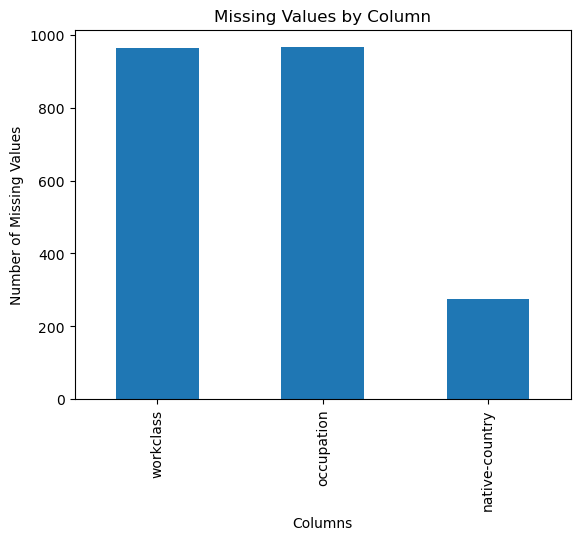

In [20]:
missing = df.isnull().sum()                                # Select only columns that contain missing values

missing = missing[missing > 0]                             # Keep only columns where missing values are greater than zero

missing.plot(kind='bar')                                   # Create a bar chart

plt.title("Missing Values by Column")                      # Add title

plt.xlabel("Columns")                                      # Label x-axis

plt.ylabel("Number of Missing Values")                     # Label y-axis

plt.show()                                                 # Display the graph

# HANDLING DUPLICATE VALUES

In [21]:
df.duplicated().sum()                                     # Count the number of completely duplicated rows

np.int64(29)

In [22]:
df_clean = df.copy()                                     # Create a copy so that we preserve the original dataset

In [23]:
df_clean = df_clean.drop_duplicates()                    # Remove duplicate rows

In [24]:
df_clean.shape                                           # Check the number of rows after removing duplicates

(48813, 15)

# CHECK INCONSISTENT VALUES 

In [25]:
df_clean["workclass"].unique()                           # Display unique values in workclass

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', '?', 'Self-emp-inc', 'Without-pay', 'Never-worked',
       nan], dtype=object)

In [26]:
df_clean["education"].unique()                           # Display unique values in education

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

In [27]:
df_clean["income"].unique()                              # Display unique values in income

array(['<=50K', '>50K', '<=50K.', '>50K.'], dtype=object)

# REMOVE EXTRA SPACES

In [28]:
text_columns = df_clean.select_dtypes(include="object").columns                     # Find all columns containing text data


In [29]:
text_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [30]:
df_clean = df.copy()                                                         # Creating a copy 

In [31]:
for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()                                 # Remove leading and trailing spaces from every text column

# COVERT MISSING SYMBOLS TO NaN

In [32]:
(df_clean == "?").sum()                                                   # Count question marks in every column

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [33]:
df_clean = df_clean.replace("?", np.nan)                              # Replace question marks with NumPy's missing value representation

In [34]:
df_clean.isnull().sum()                                               # Check missing values after converting ? to NaN

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

# HANDLE MISSING VALUES 

In [35]:
df.dropna()                                                    # Remove ROWS with Missing Values

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K.
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [36]:
df["age"].fillna(df["age"].mean())                           # Replace missing Values with Mean

0        39
1        50
2        38
3        53
4        28
         ..
48837    39
48838    64
48839    38
48840    44
48841    35
Name: age, Length: 48842, dtype: int64

In [37]:
df["workclass"].fillna(df["workclass"].mode()[0])             # Replace Values With Mode

0               State-gov
1        Self-emp-not-inc
2                 Private
3                 Private
4                 Private
               ...       
48837             Private
48838             Private
48839             Private
48840             Private
48841        Self-emp-inc
Name: workclass, Length: 48842, dtype: object

In [38]:
mode = df_clean["workclass"].mode()[0]                     

In [39]:
df_clean["workclass"] = df_clean["workclass"].fillna(mode)

In [40]:
categorical_columns = df_clean.select_dtypes(include="object").columns                    # Find all categorical columns

for col in categorical_columns:                                               # Loop through each categorical column
    mode_value = df_clean[col].mode()[0]                                      # Find the most frequently occurring value
    
    df_clean[col] = df_clean[col].fillna(mode_value)                          # Replace missing values with the most common value

In [41]:
df_clean.isnull().sum()                                         # Check whether any missing values remain

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

# DETECT OUTLIERS

In [42]:
numerical_columns = df_clean.select_dtypes(include=np.number).columns                         # Select numerical columns

numerical_columns                                                                             # Display numerical columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

# BOX PLOT FOR AGE 

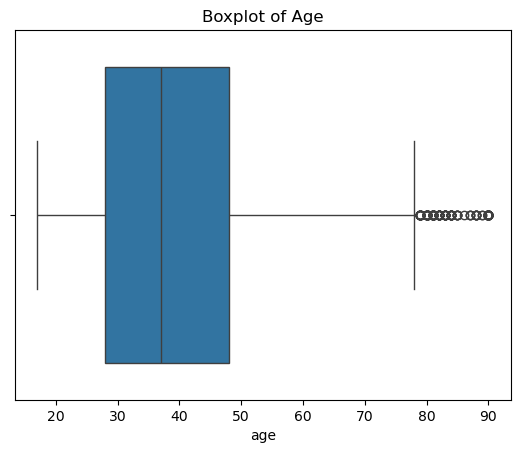

In [44]:
sns.boxplot(x=df_clean["age"])                            # Create a boxplot for age

plt.title("Boxplot of Age")                               # Add title

plt.show()                                                # Display graph

# BOX PLOT FOR HOURS WORKED 

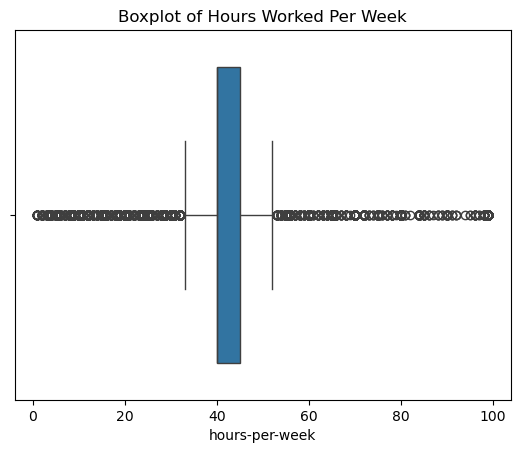

In [45]:
sns.boxplot(x=df_clean["hours-per-week"])                          # Create a boxplot for hours worked per week

plt.title("Boxplot of Hours Worked Per Week")                      # Add title

plt.show()                                                         # Display graph

# HISTOGRAM 

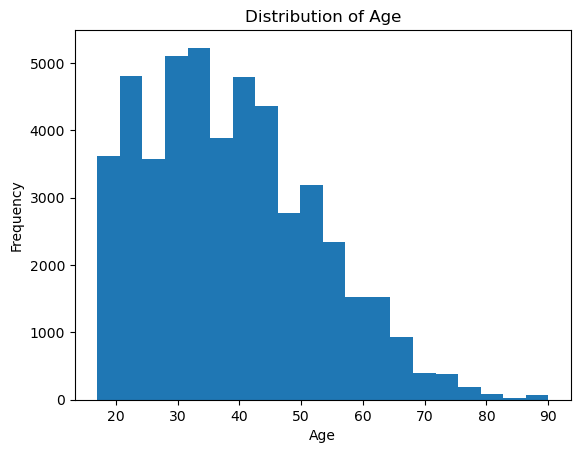

In [46]:
plt.hist(df_clean["age"], bins=20)                               # Create histogram of age

plt.title("Distribution of Age")                                 # Add title

plt.xlabel("Age")                                                # Label X-axis

plt.ylabel("Frequency")                                          # Label y-axis

plt.show()                                                       # Display graph

# DETECT OUTLIERS USING IQR

In [47]:
Q1 = df_clean["age"].quantile(0.25)                             # Select the age column

In [48]:
Q3 = df_clean["age"].quantile(0.75)                             # Calculate the third quartile

In [49]:
IQR = Q3 - Q1                                                   # Calculate the Interquartile Range

In [50]:
lower_limit = Q1 - 1.5 * IQR                                    # Calculate the lower boundary for outliers

In [51]:
upper_limit = Q3 + 1.5 * IQR                                    # Calculate the upper boundary for outliers

In [52]:
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)                              # Display the limits   

Lower Limit: -2.0
Upper Limit: 78.0


# FIND OUTLIERS

In [53]:
lower_outliers = df_clean[df_clean["age"] < lower_limit]                          # Find rows where age is below the lower limit

In [54]:
upper_outliers = df_clean[df_clean["age"] > upper_limit]                          # Find rows where age is above the upper limit

In [55]:
print("Lower Outliers:", len(lower_outliers))
print("Upper Outliers:", len(upper_outliers))                                     # Display the number of outliers

Lower Outliers: 0
Upper Outliers: 216


# CHECK INVALID AGES

In [56]:
invalid_age = df_clean[df_clean["age"] <= 0]                             # Find records where age is less than or equal to zero

In [57]:
len(invalid_age)                                                         # Display the number of invalid age records


0

# FEATURE ENGINEERING

In [59]:
df_clean["age_group"] = pd.cut(                                              # Create age groups using the age column
    df_clean["age"],
    bins=[0, 25, 40, 60, 100],
    labels=["Young Adult", "Adult", "Middle Age", "Senior"]
)


df_clean[["age", "age_group"]].head()                                        # Display the first few rows

,age,age_group
0,39,Adult
1,50,Middle Age
2,38,Adult
3,53,Middle Age
4,28,Adult


# CREATE WORK - HOUR CATEGORY

In [60]:
# Create a new feature based on hours worked per week
df_clean["work_hours_category"] = pd.cut(
    df_clean["hours-per-week"],
    bins=[0, 34, 40, 100],
    labels=["Part-time", "Full-time", "Overtime"]
)

# Display the new feature
df_clean[["hours-per-week", "work_hours_category"]].head()

,hours-per-week,work_hours_category
0,40,Full-time
1,13,Part-time
2,40,Full-time
3,40,Full-time
4,40,Full-time


# ENCODING CATEGORICAL VARIABLES

In [64]:
df_encoded = pd.get_dummies(                        # Convert categorical variables into numerical dummy variables
    df_clean,
    drop_first=True
)

df_encoded.head()                                   # Display the first five rows

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Vietnam,native-country_Yugoslavia,income_<=50K.,income_>50K,income_>50K.,age_group_Adult,age_group_Middle Age,age_group_Senior,work_hours_category_Full-time,work_hours_category_Overtime
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,38,215646,9,0,0,40,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
3,53,234721,7,0,0,40,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
4,28,338409,13,0,0,40,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False


# SCALING NUMERICAL DATA 

In [65]:
scaler = StandardScaler()                                        # Create a StandardScaler object


columns_to_scale = [
    "age",                                                       # List numerical columns that we want to scale
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]


df_encoded[columns_to_scale] = scaler.fit_transform(
    df_encoded[columns_to_scale]                                 # Apply standard scaling to these columns
)

# CHECK FINAL DATASET 

In [67]:
df_encoded.shape                                                 # Display the final number of rows and columns

(48842, 105)

In [68]:
df_encoded.isnull().sum().sum()                                  # Check whether missing values remain

np.int64(0)

In [69]:
df_encoded.duplicated().sum()                                    # Check for duplicate rows after cleaning

np.int64(29)

In [70]:
df_encoded.info()                                                # Display final information about the cleaned dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Columns: 105 entries, age to work_hours_category_Overtime
dtypes: bool(99), float64(6)
memory usage: 6.8 MB


# SAVE CLEAN DATASET

In [71]:
# Save the cleaned dataset as a CSV file
df_encoded.to_csv(
    "adult_cleaned_dataset.csv",
    index=False
)